**Description Of the features of the dataset:**


Y – Latitude coordinate of the observation station.

X – Longitude coordinate of the observation station.

data_payload_id – Unique identifier for the data record.

instance_datetime – Timestamp when the data was recorded.

url – URL reference to the data source.

agency – Organization responsible for the data.

platform_type – Type of platform (e.g., station, balloon, etc.).

platform_id – Numeric ID for the platform.

platform_name – Name of the observation platform or station.

gaw_id – Global Atmosphere Watch ID of the platform.

instrument_name – Name of the instrument used for measurement.

instrument_model – Model of the instrument.

instrument_number – Instrument's identification number.

monthly_date – Date associated with monthly aggregated data.

monthly_columno3 – Monthly average ozone column value.

monthly_stddevo3 – Standard deviation of the monthly ozone values.

monthly_npts – Number of observations used in monthly average.

daily_date – Date of the daily observation.

daily_wlcode – Wavelength code used during observation.

daily_obscode – Observation code (e.g., method or technique).

daily_columno3 – Daily ozone column measurement (Dobson Units).

daily_stddevo3 – Standard deviation of the daily ozone value.

daily_utc_begin – UTC time when observation began.

daily_utc_end – UTC time when observation ended.

daily_utc_mean – Mean UTC time of observation.

daily_nobs – Number of observations for that day.

daily_mmu – Measurement uncertainty for daily ozone.

daily_columnso2 – Daily SO₂ (sulfur dioxide) column measurement.

latest_observation – Flag indicating if this is the most recent data (0 or 1).

country – Country of the observation station.

scientific_authority – Name of the responsible scientist or authority.

version – Version number of the data record.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.linear_model import  LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler ,MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

In [14]:
df=pd.read_csv('New Dataset/spain.csv')
df.head()


,Y,X,data_payload_id,instance_datetime,url,agency,platform_type,platform_id,platform_name,gaw_id,...,daily_utc_begin,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,latest_observation,country,scientific_authority,version
0,28.46,-16.25,2306481,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,9.15,10.52,9.60,4.0,2.181,-0.5,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
1,28.46,-16.25,2306502,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,12.50,17.88,15.22,12.0,1.421,-1.4,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
2,28.46,-16.25,2306482,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,8.85,14.03,10.80,16.0,1.638,-0.9,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
3,28.46,-16.25,2306480,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,12.83,17.27,15.41,10.0,1.602,-0.6,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0
4,28.46,-16.25,2306483,2025/03/05 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,AEMET,STN,401,Santa Cruz (Tenerife),SCO,...,9.55,17.55,15.04,19.0,1.680,-0.8,0,ESP,MIGUEL HERNANDEZ MARTINEZ DE LA PEÑA,0.0


In [15]:
df=df.drop(['Y', 'X', 'data_payload_id', 'instance_datetime', 'url', 'agency',
       'platform_type', 'platform_id', 'platform_name', 'gaw_id',
       'instrument_name', 'instrument_model', 'instrument_number',
       'monthly_date', 'monthly_stddevo3', 'monthly_npts','daily_stddevo3',
        'daily_wlcode', 'daily_obscode', 'monthly_columno3',
        'daily_utc_begin', 'daily_utc_end', 'daily_utc_mean',
       'daily_nobs', 'daily_mmu', 'daily_columnso2', 'latest_observation',
       'country', 'scientific_authority', 'version'], axis = 1)
df.head()

,daily_date,daily_columno3
0,2025-03-06,280.5
1,2025-03-27,310.2
2,2025-03-07,306.3
3,2025-03-05,319.4
4,2025-03-08,313.9


In [16]:
print(f"Date Range: {df.loc[:,'daily_date'][len(df)-1]} to {df.loc[:,'daily_date'][0]}")

Date Range: 1976-01-21 to 2025-03-06


In [17]:
df=df.drop_duplicates()
df=df.dropna()
# df=df.set_index('daily_date')
df.head()


,daily_date,daily_columno3
0,2025-03-06,280.5
1,2025-03-27,310.2
2,2025-03-07,306.3
3,2025-03-05,319.4
4,2025-03-08,313.9


In [18]:
round(df.describe(), 3)

,daily_columno3
count,65510.000
mean,310.114
std,34.389
min,-91.500
25%,286.000
50%,305.000
75%,328.600
max,521.800


In [19]:
df.head()
df.dtypes

daily_date         object
daily_columno3    float64
dtype: object

<Figure size 1200x600 with 0 Axes>

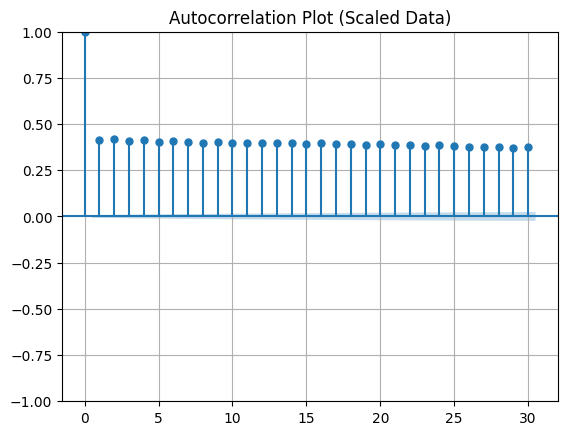

✅ Autocorrelation remains significant for all plotted lags.


In [20]:

acf_vals, confint = acf(df['daily_columno3'], nlags=30, alpha=0.05)

# 4. Calculate threshold from confidence interval
threshold = (confint[:,1] - confint[:,0]) / 2

# 5. Find first inconsistent lag
inconsistent_lag = None
for i, val in enumerate(acf_vals):
    if i == 0:  # Skip lag 0
        continue
    if abs(val) < threshold[i]:
        inconsistent_lag = i
        break

# 6. Plot ACF
plt.figure(figsize=(12,6))
plot_acf(df['daily_columno3'], lags=30, alpha=0.05)
plt.title('Autocorrelation Plot (Scaled Data)')
plt.grid()
plt.show()

# 7. Print result
if inconsistent_lag:
    print(f"👉 Autocorrelation becomes inconsistent after lag {inconsistent_lag}.")
else:
    print("✅ Autocorrelation remains significant for all plotted lags.")



In [21]:
df.head()

,daily_date,daily_columno3
0,2025-03-06,280.5
1,2025-03-27,310.2
2,2025-03-07,306.3
3,2025-03-05,319.4
4,2025-03-08,313.9


In [22]:
# 2. Sort the dataframe by the full date (oldest to latest)
df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)

# Rolling average feature (3-day) - To Avoid data leakage, we shift the column by 1 day
df['rolling_avg'] = df['daily_columno3'].shift(1).rolling(window=7).mean()

# Exponential moving average feature (7-day) - To Avoid data leakage, we shift the column by 1 day
df['ema_avg'] = df['daily_columno3'].shift(1).ewm(span=7, adjust=False).mean()


df['lag1'] = df['daily_columno3'].shift(1)
df['lag2'] = df['daily_columno3'].shift(2)
df['lag3'] = df['daily_columno3'].shift(3)
df['lag4'] = df['daily_columno3'].shift(4)
df['lag5'] = df['daily_columno3'].shift(5)
df['lag6'] = df['daily_columno3'].shift(6)
df['lag7'] = df['daily_columno3'].shift(7)
df['lag8'] = df['daily_columno3'].shift(8)
df['lag9'] = df['daily_columno3'].shift(9)
df['lag10'] = df['daily_columno3'].shift(10)
df['lag11'] = df['daily_columno3'].shift(11)
df['lag12'] = df['daily_columno3'].shift(12)
df['lag13'] = df['daily_columno3'].shift(13)
df['lag14'] = df['daily_columno3'].shift(14)
df['lag15'] = df['daily_columno3'].shift(15)
df.dropna(inplace=True)
print(df.shape)
df.head()

(65495, 19)


,daily_date,daily_columno3,rolling_avg,ema_avg,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14,lag15
15,1976-07-05,305.9,324.714286,318.785662,295.2,296.2,342.0,365.4,332.2,332.2,309.8,330.3,347.8,347.8,351.7,308.9,296.2,257.2,264.0
16,1976-07-06,307.9,324.157143,315.564247,305.9,295.2,296.2,342.0,365.4,332.2,332.2,309.8,330.3,347.8,347.8,351.7,308.9,296.2,257.2
17,1976-07-07,297.2,320.685714,313.648185,307.9,305.9,295.2,296.2,342.0,365.4,332.2,332.2,309.8,330.3,347.8,347.8,351.7,308.9,296.2
18,1976-07-08,290.3,315.685714,309.536139,297.2,307.9,305.9,295.2,296.2,342.0,365.4,332.2,332.2,309.8,330.3,347.8,347.8,351.7,308.9
19,1976-07-09,293.3,304.957143,304.727104,290.3,297.2,307.9,305.9,295.2,296.2,342.0,365.4,332.2,332.2,309.8,330.3,347.8,347.8,351.7


In [23]:
df.tail()

,daily_date,daily_columno3,rolling_avg,ema_avg,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14,lag15
65505,2025-03-31,304.2,318.200000,321.528513,337.5,323.5,296.8,314.8,317.0,310.6,327.2,340.4,312.4,339.1,304.3,318.1,319.2,342.9,308.9
65506,2025-03-31,326.3,314.914286,317.196385,304.2,337.5,323.5,296.8,314.8,317.0,310.6,327.2,340.4,312.4,339.1,304.3,318.1,319.2,342.9
65507,2025-03-31,332.6,317.157143,319.472289,326.3,304.2,337.5,323.5,296.8,314.8,317.0,310.6,327.2,340.4,312.4,339.1,304.3,318.1,319.2
65508,2025-03-31,291.9,319.385714,322.754217,332.6,326.3,304.2,337.5,323.5,296.8,314.8,317.0,310.6,327.2,340.4,312.4,339.1,304.3,318.1
65509,2025-03-31,325.0,316.114286,315.040662,291.9,332.6,326.3,304.2,337.5,323.5,296.8,314.8,317.0,310.6,327.2,340.4,312.4,339.1,304.3


**Using Rolling Average**

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.068
MAE : 0.049
R2  : 50.26 %

----- Decision Tree -----
RMSE: 0.094
MAE : 0.068
R2  : 3.47 %

----- Random Forest -----
RMSE: 0.068
MAE : 0.049
R2  : 49.54 %

----- Gradient Boosting -----
RMSE: 0.068
MAE : 0.049
R2  : 50.37 %

----- Support Vector Regressor -----
RMSE: 0.071
MAE : 0.053
R2  : 45.07 %



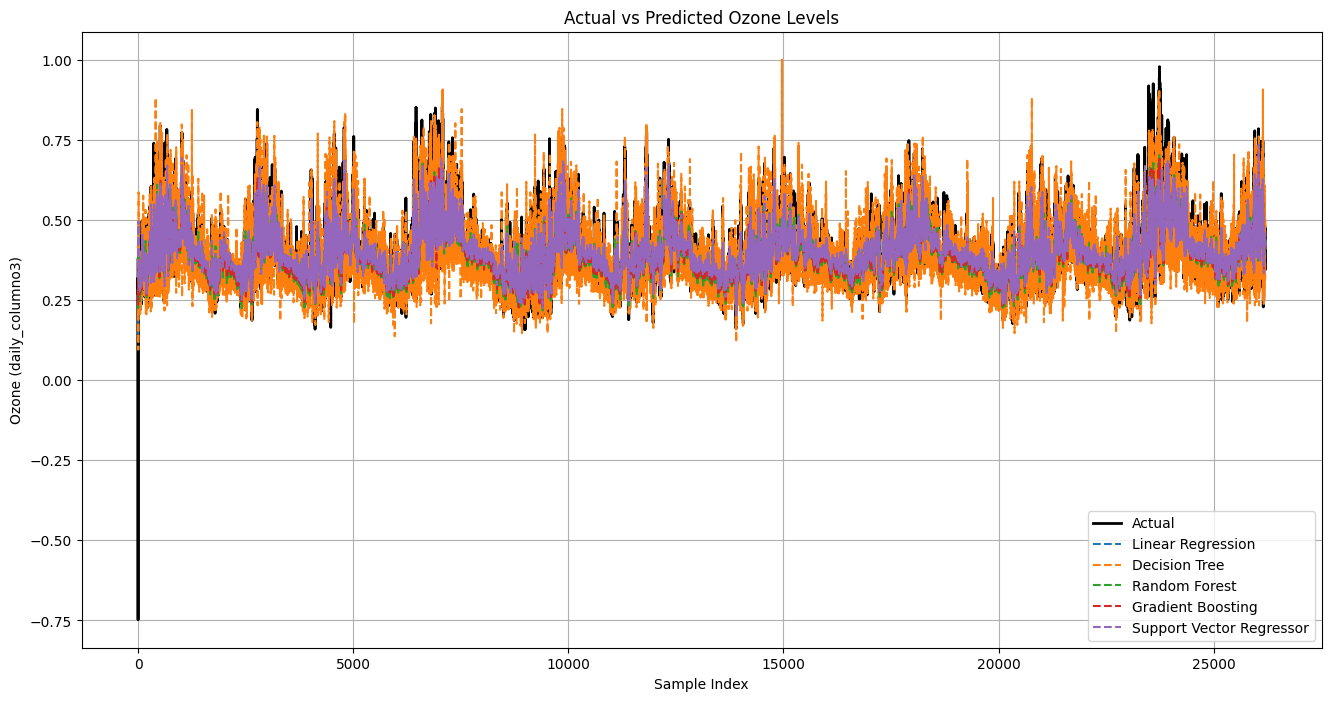

In [25]:
minmax_x = MinMaxScaler()
minmax_y= MinMaxScaler()

X = df[['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7',
        'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag15','rolling_avg']]
y = df['daily_columno3']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, shuffle=False)
X_train = minmax_x.fit_transform(X_train)
y_train = minmax_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
X_test = minmax_x.transform(X_test)
y_test = minmax_y.transform(y_test.values.reshape(-1, 1)).flatten()

# STEP 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR()
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

plt.figure(figsize=(16, 8))

# Actual data
plt.plot(np.arange(len(y_test)), y_test, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(np.arange(len(y_test)), res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Sample Index')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()

**Using Exponantial Average**

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.068
MAE : 0.049
R2  : 50.28 %

----- Decision Tree -----
RMSE: 0.095
MAE : 0.069
R2  : 1.42 %

----- Random Forest -----
RMSE: 0.068
MAE : 0.049
R2  : 49.38 %

----- Gradient Boosting -----
RMSE: 0.068
MAE : 0.049
R2  : 50.39 %

----- Support Vector Regressor -----
RMSE: 0.071
MAE : 0.053
R2  : 45.13 %



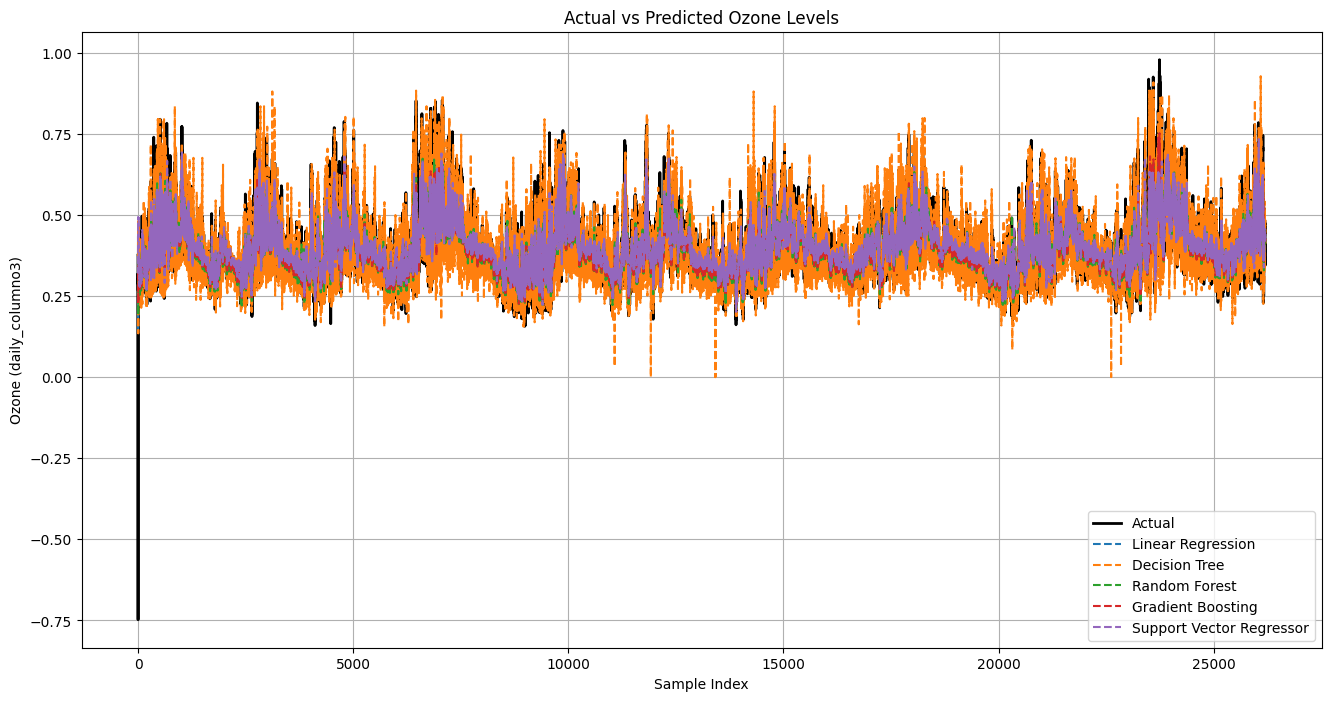

In [26]:
minmax_x = MinMaxScaler()
minmax_y= MinMaxScaler()

X = df[['lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7',
        'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag15','ema_avg']]
y = df['daily_columno3']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, shuffle=False)
X_train = minmax_x.fit_transform(X_train)
y_train = minmax_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
X_test = minmax_x.transform(X_test)
y_test = minmax_y.transform(y_test.values.reshape(-1, 1)).flatten()

# STEP 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR()
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

plt.figure(figsize=(16, 8))

# Actual data
plt.plot(np.arange(len(y_test)), y_test, label='Actual', color='black', linewidth=2)

# Predictions from each model
for name, res in results.items():
    plt.plot(np.arange(len(y_test)), res['Predictions'], label=name, linestyle='--')

plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Sample Index')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

from sklearn.model_selection import RandomizedSearchCV,ParameterGrid

# Ensure data is float32 to reduce memory usage
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR()
}

# Define hyperparameter grids
param_grids = {
    'Linear Regression': {},

    'Decision Tree': {
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    'Random Forest': {
        'n_estimators': [100, 150],
        'max_depth': [10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    'Gradient Boosting': {
        'n_estimators': [100, 150],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5]
    },

    'Support Vector Regressor': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'epsilon': [0.1, 0.01]
    }
}

# Use RandomizedSearchCV for heavier models
use_randomized_search = {'Random Forest', 'Gradient Boosting', 'Support Vector Regressor'}

# Run tuning and evaluation
best_models = {}
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    if param_grids[name]:  # If model has tunable parameters
        if name in use_randomized_search:
            search = RandomizedSearchCV(
                model, param_distributions=param_grids[name],
                n_iter=10, cv=3,scoring='r2', n_jobs=1,
                verbose=1, random_state=42
            )
        else:
            search = RandomizedSearchCV(
                model, param_distributions=param_grids[name],
                n_iter=len(list(ParameterGrid(param_grids[name]))),
                cv=3, scoring='r2', n_jobs=1, verbose=1,
                random_state=42
            )

        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
        print(f"{name} Best Parameters: {search.best_params_}")
    else:
        model.fit(X_train, y_train)
        best_models[name] = model

    # Make predictions and calculate metrics
    preds = best_models[name].predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        'Model': best_models[name],
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# Print metrics
print("\nModel Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# Plot predictions
plt.figure(figsize=(16, 8))
plt.plot(np.arange(len(y_test)), y_test, label='Actual', color='black', linewidth=2)
for name, res in results.items():
    plt.plot(np.arange(len(y_test)), res['Predictions'], label=name, linestyle='--')
plt.title('Actual vs Predicted Ozone Levels (with Hyperparameter Tuning)')
plt.xlabel('Sample Index')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()



Training Linear Regression...

Training Decision Tree...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Decision Tree Best Parameters: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}

Training Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Random Forest Best Parameters: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}

Training Gradient Boosting...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Gradient Boosting Best Parameters: {'n_estimators': 150, 'min_samples_split': 5, 'max_depth': 3, 'learning_rate': 0.1}

Training Support Vector Regressor...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
